In [1]:
%load_ext autoreload
%autoreload 2

In [39]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
import seaborn as sns
sns.set_theme()

In [7]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import GHANA_GDF, ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH, ETHZ_COCOA_MAP_FILEPATH, SILVER_FOLDERPATH, ETHZ_COCOA_MAP_UINT8_FILEPATH

In [8]:
# Load sites
sites = joblib.load(SILVER_FOLDERPATH / "enriched-sites.pkl")
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


In [14]:
# Figure out all locations of interests 
lat_lons = []
for s in sites:
    lat_lons += s.lat_lons
lon_lats = [(lon, lat) for lat, lon in lat_lons]

In [20]:
lonlat_to_val = {}

with rasterio.open(ETHZ_COCOA_MAP_FILEPATH) as src:
    print(f"Raster CRS: {src.crs}")

    for lon_lat, val in zip(lon_lats, src.sample(lon_lats)):
        # val comes back as an array matching the number of bands in the TIFF
        lonlat_to_val[lon_lat] = float(val[0])

Raster CRS: EPSG:4326


Text(0.5, 1.0, 'ETHZ-probs histogram of the max-pooling-amongst-trees for each 155 site')

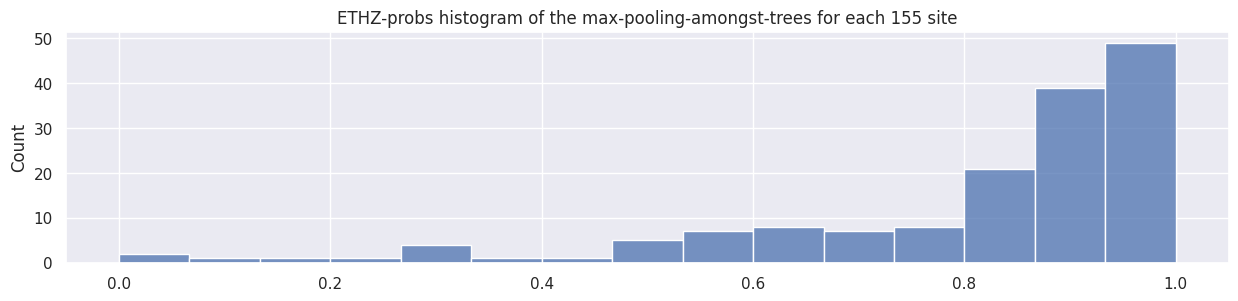

In [31]:
site_name_to_probs = {}
for s in sites:
    probs = []
    for lat, lon in s.lat_lons:
        probs.append(lonlat_to_val[(lon, lat)])
    site_name_to_probs[s.name] = probs

plt.figure(figsize=(15,3))
sns.histplot([max(e) for e in site_name_to_probs.values()])
plt.title(f"ETHZ-probs histogram of the max-pooling-amongst-trees for each {len(sites)} site")

In [38]:
for site_name, probs in site_name_to_probs.items():
    if max(probs) > 0.2:
        continue
    print(site_name, max(probs))

DU03 0.13958334922790527
KU06 0.0
KU13 0.018518507480621338
SB13 0.07147949934005737
